/var/folders/k1/fj7cl3m153q3m7z92s_nt1hw0000gn/T/ipykernel_58677/639115494.py:10: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skio.imshow(im)
/var/folders/k1/fj7cl3m153q3m7z92s_nt1hw0000gn/T/ipykernel_58677/639115494.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skio.show()


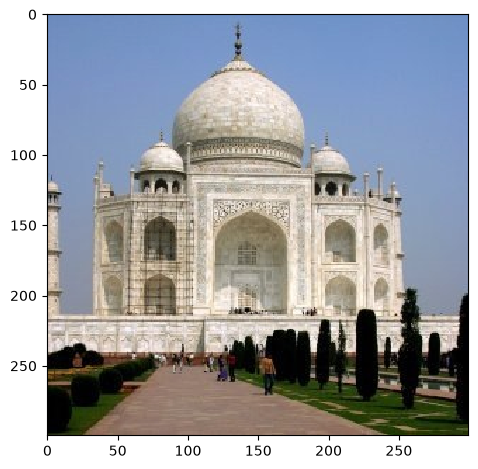

(300, 300, 3)

In [34]:
import numpy as np
import skimage as sk
import skimage.io as skio

imname = 'images/taj.jpg'

im = skio.imread(imname)
im = sk.img_as_float(im)

skio.imshow(im)
skio.show()
im.shape

In [ ]:
def convolution(img, kernel, padding=None):
    h, w = kernel.shape
    m, n = img.shape[:2]
    kernel = kernel[::-1, ::-1]

    if padding == "same":
        pad_h = h // 2
        pad_w = w // 2
    elif padding == "full":
        pad_h = h - 1
        pad_w = w - 1
    else:
        pad_h = 0
        pad_w = 0
        
    if img.ndim == 2:
        img_pad = np.pad(
            img,
            ((pad_h, pad_h), (pad_w, pad_w))
        )
    else:
        img_pad = np.pad(
            img,
            ((pad_h, pad_h), (pad_w, pad_w), (0, 0))
        )

    h_out = img_pad.shape[0] - h + 1
    w_out = img_pad.shape[1] - w + 1

    if img.ndim == 2:
        img_out = np.zeros((h_out, w_out))
    else:
        img_out = np.zeros((h_out, w_out, img.shape[2]))

    for i in range(h_out):
        for j in range(w_out):
            if img.ndim == 2:
                val = 0
                for k in range(h):
                    for l in range(w):
                        val += kernel[k, l] * img_pad[i+k, j+l]
                img_out[i, j] = val

            else:
                val = np.zeros(img.shape[2])

                for k in range(h):
                    for l in range(w):
                        val += kernel[k, l] * img_pad[i+k, j+l, :]

                img_out[i, j, :] = val

    return img_out

/var/folders/k1/fj7cl3m153q3m7z92s_nt1hw0000gn/T/ipykernel_58677/3247606471.py:8: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skio.imshow(im_blurred)
/var/folders/k1/fj7cl3m153q3m7z92s_nt1hw0000gn/T/ipykernel_58677/3247606471.py:9: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skio.show()


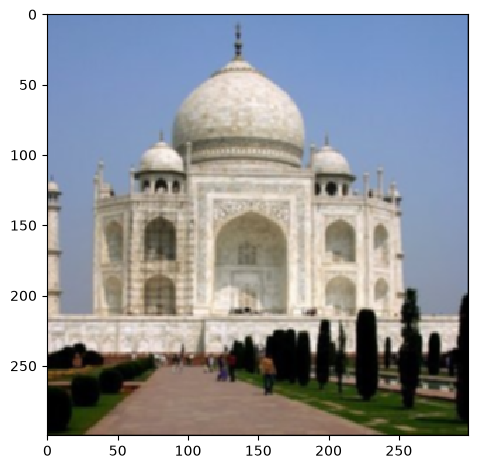

In [35]:
import cv2

gaussian_vector = cv2.getGaussianKernel(3,1)
gaussian_filter = np.outer(gaussian_vector, gaussian_vector)

im_blurred = convolution(im, gaussian_filter, "same")

skio.imshow(im_blurred)
skio.show()

/var/folders/k1/fj7cl3m153q3m7z92s_nt1hw0000gn/T/ipykernel_58677/3247606471.py:8: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skio.imshow(im_blurred)
/var/folders/k1/fj7cl3m153q3m7z92s_nt1hw0000gn/T/ipykernel_58677/3247606471.py:9: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skio.show()


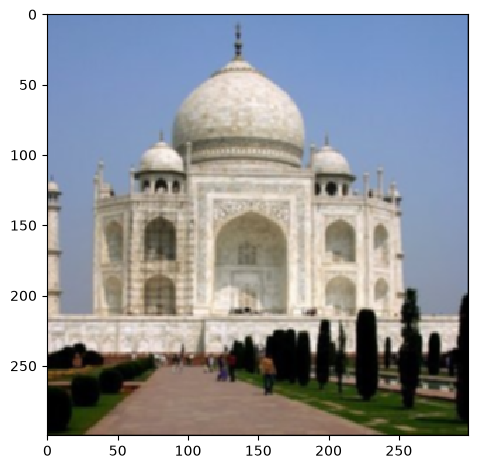

In [37]:
import cv2

gaussian_vector = cv2.getGaussianKernel(3,1)
gaussian_filter = np.outer(gaussian_vector, gaussian_vector)

im_blurred = convolution(im, gaussian_filter, "same")

skio.imshow(im_blurred)
skio.show()

/var/folders/k1/fj7cl3m153q3m7z92s_nt1hw0000gn/T/ipykernel_58677/620773147.py:4: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skio.imshow(im_scale)
/var/folders/k1/fj7cl3m153q3m7z92s_nt1hw0000gn/T/ipykernel_58677/620773147.py:5: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skio.show()


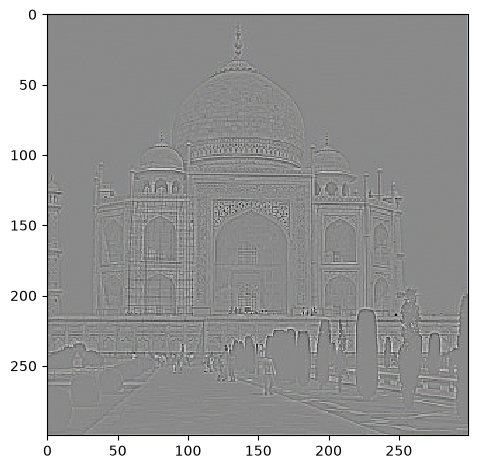

In [38]:
im_hf = im - im_blurred
im_scale = (im_hf - im_hf.min()) / (im_hf.max() - im_hf.min())

skio.imshow(im_scale)
skio.show()

/var/folders/k1/fj7cl3m153q3m7z92s_nt1hw0000gn/T/ipykernel_58677/2115379609.py:3: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skio.imshow(sharpened_ims[0])
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.1988615027668266..1.137719376311921].
/var/folders/k1/fj7cl3m153q3m7z92s_nt1hw0000gn/T/ipykernel_58677/2115379609.py:4: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skio.show()


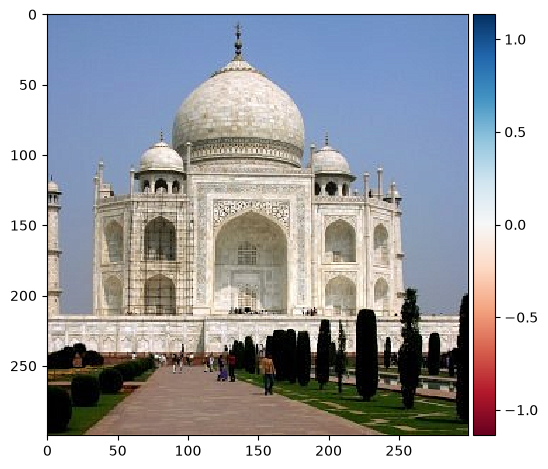

In [39]:
sharpened_ims = [im + alpha * im_hf for alpha in [0.5, 1, 2, 5, 10]]

skio.imshow(sharpened_ims[0])
skio.show()

/var/folders/k1/fj7cl3m153q3m7z92s_nt1hw0000gn/T/ipykernel_58677/852528765.py:1: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skio.imshow(sharpened_ims[1])
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.4055661427885552..1.2754387526238422].
/var/folders/k1/fj7cl3m153q3m7z92s_nt1hw0000gn/T/ipykernel_58677/852528765.py:2: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skio.show()


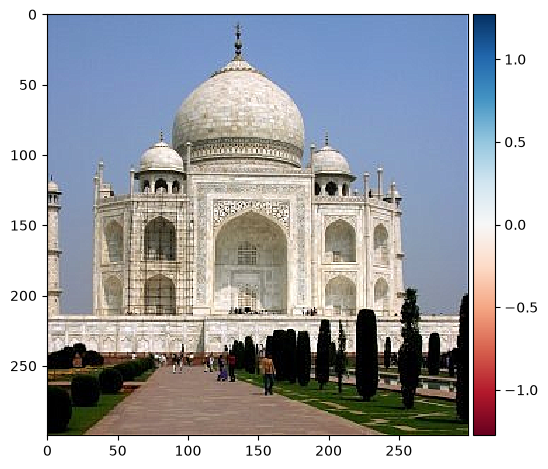

In [40]:
skio.imshow(sharpened_ims[1])
skio.show()

/var/folders/k1/fj7cl3m153q3m7z92s_nt1hw0000gn/T/ipykernel_58677/477366797.py:1: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skio.imshow(sharpened_ims[2])
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8189754228320123..1.5653328695758582].
/var/folders/k1/fj7cl3m153q3m7z92s_nt1hw0000gn/T/ipykernel_58677/477366797.py:2: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skio.show()


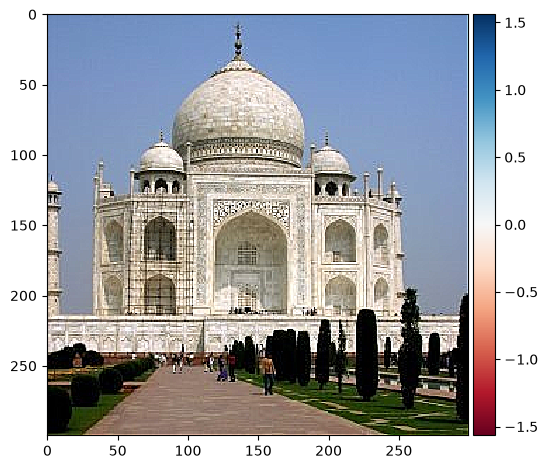

In [41]:
skio.imshow(sharpened_ims[2])
skio.show()

In [42]:
def sharpen(img, alpha):
    img_blurred = convolution(img, gaussian_filter, "same")
    return img + alpha * (img - img_blurred)

/var/folders/k1/fj7cl3m153q3m7z92s_nt1hw0000gn/T/ipykernel_58677/2022597897.py:3: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skio.imshow(im1)
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.4055661427885552..1.2754387526238422].
/var/folders/k1/fj7cl3m153q3m7z92s_nt1hw0000gn/T/ipykernel_58677/2022597897.py:4: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skio.show()


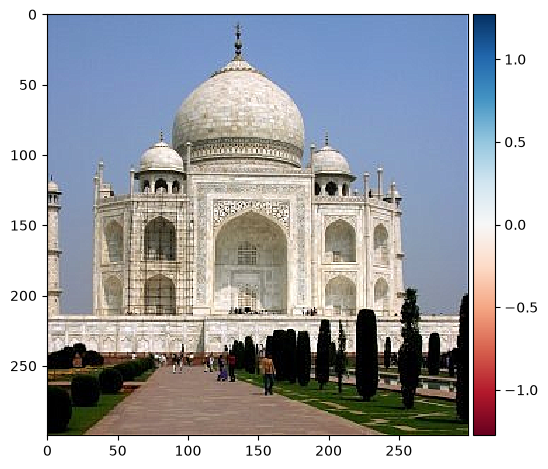

In [43]:
im1 = sharpen(im, 1)

skio.imshow(im1)
skio.show()

/var/folders/k1/fj7cl3m153q3m7z92s_nt1hw0000gn/T/ipykernel_58677/2512111148.py:3: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skio.imshow(im2)
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.2651176395211154..1.1745389903800527].
/var/folders/k1/fj7cl3m153q3m7z92s_nt1hw0000gn/T/ipykernel_58677/2512111148.py:4: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skio.show()


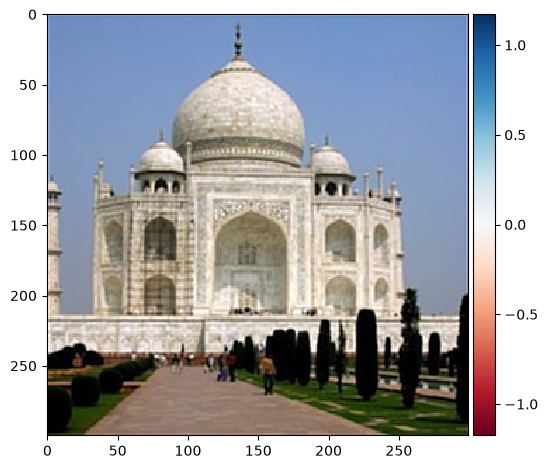

In [44]:
im2 = sharpen(convolution(im1, gaussian_filter, "same"), 1)

skio.imshow(im2)
skio.show()

/var/folders/k1/fj7cl3m153q3m7z92s_nt1hw0000gn/T/ipykernel_58677/2205849112.py:4: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skio.imshow(cat)
/var/folders/k1/fj7cl3m153q3m7z92s_nt1hw0000gn/T/ipykernel_58677/2205849112.py:5: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skio.show()


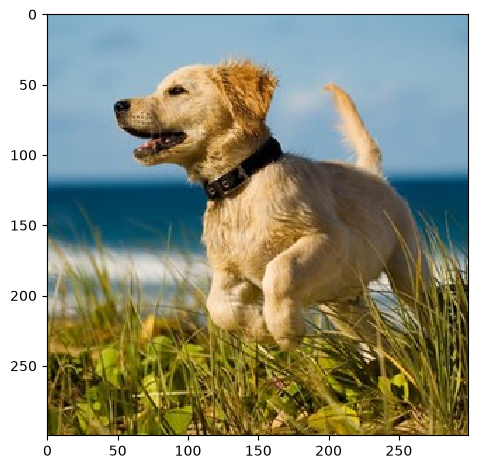

In [51]:
cat = skio.imread('images/dog.jpg')
cat = sk.img_as_float(cat)

skio.imshow(cat)
skio.show()

/var/folders/k1/fj7cl3m153q3m7z92s_nt1hw0000gn/T/ipykernel_58677/1238907411.py:2: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skio.imshow(cat)
/var/folders/k1/fj7cl3m153q3m7z92s_nt1hw0000gn/T/ipykernel_58677/1238907411.py:3: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skio.show()


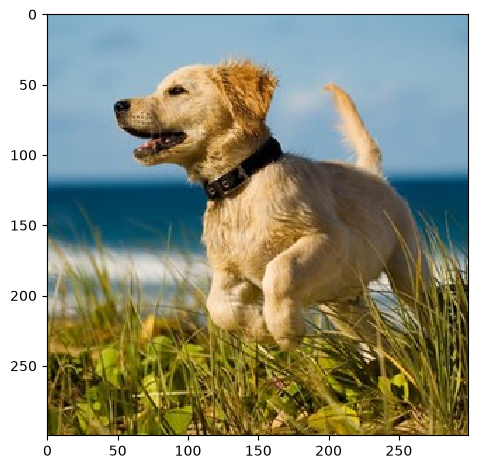

In [53]:
cat_sharp = sharpen(cat, 2)
skio.imshow(cat)
skio.show()